# **C09 - Valuación de opciones exóticas y de barrera**
## **Simulación de Procesos Financieros**

---

**Autor:** Francisco Uriel Ledezma Chávez  
**Carrera:** Ingeniería Financiera  
**Institución:** ITESO — Universidad Jesuita de Guadalajara  
**Semestre:** 5° — Simulación de Procesos Financieros  
**Fecha de realización:** 21 de septiembre de 2026

---

**Ejercicio:** conservar la trayectoria completa del precio del activo para valuar tres contratos cuyo pago depende del camino recorrido —la put europea, la asiática y la lookback— y construir después las cuatro variantes de barrera de la put europea, comprobando que la versión in y la versión out sumen exactamente el contrato sin barrera.

El notebook anterior mostró que promediar los precios de cada camino produce un contrato distinto del que sólo mira el vencimiento, y aquí esa idea se lleva hasta su forma extrema, ya que la opción de barrera no modifica la fórmula del pago sino la condición bajo la cual ese pago llega a existir, de modo que dos contratos con idéntico payoff terminal pueden valer cifras muy distintas según el precio haya tocado o no un nivel determinado durante el año.

## Índice de contenidos

1. Sección 1 — Tres rutas fijas y la dependencia del camino
2. Sección 2 — Generador de trayectorias y funciones de pago
3. Sección 3 — Parámetros y simulación
4. Sección 4 — Valor de las opciones exóticas
5. Sección 5 — Opciones de barrera
6. Sección 6 — Conclusiones

## Importación de bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(21)

## 1. Tres rutas fijas y la dependencia del camino

Antes de simular conviene fijar la intuición sobre tres rutas escritas a mano, cada una de siete precios que parten de 100, ya que sobre ellas puede leerse a simple vista qué mira cada contrato: el precio final, el promedio de todo el recorrido o el extremo que el recorrido llegó a visitar.

In [2]:
Ruta_1 = [100, 111, 105, 90, 95, 102, 100]
Ruta_2 = [100, 102, 105, 107, 109, 105, 107]
Ruta_3 = [100, 110, 121, 120, 108, 100, 99]

for nombre, ruta in [("Ruta 1", Ruta_1), ("Ruta 2", Ruta_2), ("Ruta 3", Ruta_3)]:
    ruta = np.array(ruta)
    print(f"{nombre}: promedio = {ruta.mean():8.4f}   promedio - 100 = {ruta.mean() - 100:7.4f}"
          f"   máximo = {ruta.max():3d}   mínimo = {ruta.min():3d}   precio final = {ruta[-1]:3d}")

Ruta 1: promedio = 100.4286   promedio - 100 =  0.4286   máximo = 111   mínimo =  90   precio final = 100
Ruta 2: promedio = 105.0000   promedio - 100 =  5.0000   máximo = 109   mínimo = 100   precio final = 107
Ruta 3: promedio = 108.2857   promedio - 100 =  8.2857   máximo = 121   mínimo =  99   precio final =  99


La Ruta 3 es la que muestra con mayor claridad por qué el camino importa, pues termina en 99 y por ello una put europea de strike 100 pagaría apenas un peso, mientras que su promedio de 108.2857 deja sin valor alguno a la put asiática y su máximo de 121 haría que una put lookback pagara 22 pesos sobre ese mismo recorrido.

El contraste con las otras dos rutas ordena el resto del ejercicio, ya que la Ruta 1 cierra exactamente en 100 con un promedio de 100.4286 después de haber caído hasta 90, y la Ruta 2 sube de forma sostenida hasta un promedio de 105 sin alejarse nunca del punto de partida, de manera que un mismo activo produce pagos distintos según el contrato observe el final, la media o el extremo del camino.

## 2. Generador de trayectorias y funciones de pago

El precio se propaga mediante el movimiento browniano geométrico que ya se utilizó en los ejercicios anteriores, donde cada paso parte del precio del día previo y aplica una deriva corregida por la varianza junto con una perturbación normal independiente.

$$S_{t+\Delta t} = S_t \exp\left[\left(r - \frac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t}\,Z\right], \qquad Z \sim N(0,1)$$

La diferencia frente al esquema de un solo salto que basta para la opción europea, conservado aquí como `precio_terminal`, es que `create_paths` guarda los $n+1$ precios de cada camino dentro de una matriz, ya que sin esa matriz no existen ni el promedio, ni el máximo, ni la condición de haber tocado una barrera.

In [3]:
def precio_terminal(r, sigma, T, S0):
    return S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * np.random.normal(0, 1))


def create_paths(S0, r, std, T, n, M):
    dt = T / n
    paths = np.zeros((M, n + 1))
    paths[:, 0] = S0
    for i in range(1, n + 1):
        Z = np.random.standard_normal(M)
        paths[:, i] = paths[:, i - 1] * np.exp((r - 0.5 * std ** 2) * dt + std * np.sqrt(dt) * Z)
    return paths

Las tres funciones de pago comparten la misma firma y se distinguen únicamente por la referencia de precio que toman, pues la europea mira $S_T$, la asiática el promedio de los $n+1$ precios del camino y la lookback el extremo favorable al tenedor, de modo que la put lookback paga $\max(S)-S_T$ y la call lookback paga $S_T-\min(S)$.

In [4]:
def payoff_europea(paths, K, call=True):
    precios_finales = paths[:, -1]
    if call:
        return np.maximum(precios_finales - K, 0)
    else:
        return np.maximum(K - precios_finales, 0)


def payoff_asiatica(paths, K, call=True):
    precios_promedio = np.mean(paths, axis=1)
    if call:
        return np.maximum(precios_promedio - K, 0)
    else:
        return np.maximum(K - precios_promedio, 0)


def payoff_lookback(paths, K, call=True):
    precios_finales = paths[:, -1]
    if call:
        return np.maximum(precios_finales - np.min(paths, axis=1), 0)
    else:
        return np.maximum(np.max(paths, axis=1) - precios_finales, 0)

Las cuatro funciones de barrera no redefinen el pago sino que lo condicionan, ya que reciben una función de payoff y la activan o la anulan según el camino haya cruzado el nivel $B$, con lo cual la variante in paga sólo si la barrera fue tocada en algún momento y la variante out paga sólo si nunca llegó a tocarse.

El monitoreo resulta discreto porque la condición se evalúa sobre los precios guardados y no sobre el recorrido continuo, y esa diferencia no es neutral, dado que un camino puede cruzar la barrera entre dos cierres consecutivos y regresar sin dejar rastro en la matriz, lo cual subestima de manera sistemática el valor de las variantes in y sobreestima el de las variantes out.

In [5]:
def up_and_in(B, payoff, paths, K, call=True):
    barrera_tocada = np.max(paths, axis=1) >= B
    payoffs = payoff(paths, K, call)
    return np.where(barrera_tocada, payoffs, 0)


def up_and_out(B, payoff, paths, K, call=True):
    barrera_tocada = np.max(paths, axis=1) >= B
    payoffs = payoff(paths, K, call)
    return np.where(barrera_tocada, 0, payoffs)


def down_and_in(B, payoff, paths, K, call=True):
    barrera_tocada = np.min(paths, axis=1) <= B
    payoffs = payoff(paths, K, call)
    return np.where(barrera_tocada, payoffs, 0)


def down_and_out(B, payoff, paths, K, call=True):
    barrera_tocada = np.min(paths, axis=1) <= B
    payoffs = payoff(paths, K, call)
    return np.where(barrera_tocada, 0, payoffs)

## 3. Parámetros y simulación

La simulación toma un activo de 100 pesos con strike en el mismo nivel, tasa libre de riesgo de 5%, volatilidad de 20% y horizonte de un año dividido en 252 pasos diarios, sobre el cual se generan 10,000 trayectorias, mientras que las barreras se fijan en 110 por arriba y en 80 por abajo para vigilar un movimiento moderado al alza y una caída pronunciada.

In [6]:
S0 = 100
K = 100
r = 0.05
std = 0.2
T = 1
n = 252
M = 10000
B_alta = 110
B_baja = 80

paths = create_paths(S0, r, std, T, n, M)

payoff_put_europea = payoff_europea(paths, K, call=False)
payoff_put_asiatica = payoff_asiatica(paths, K, call=False)
payoff_put_lookback = payoff_lookback(paths, K, call=False)

payoff_put_up_and_in = up_and_in(B_alta, payoff_europea, paths, K, call=False)
payoff_put_up_and_out = up_and_out(B_alta, payoff_europea, paths, K, call=False)
payoff_put_down_and_in = down_and_in(B_baja, payoff_europea, paths, K, call=False)
payoff_put_down_and_out = down_and_out(B_baja, payoff_europea, paths, K, call=False)

print("Trayectorias simuladas:", paths.shape[0], "· precios por trayectoria:", paths.shape[1])
print(f"Trayectorias que alcanzan la barrera alta de {B_alta}: {np.sum(np.max(paths, axis=1) >= B_alta):5d}"
      f"  ({np.mean(np.max(paths, axis=1) >= B_alta):6.2%})")
print(f"Trayectorias que alcanzan la barrera baja de {B_baja}: {np.sum(np.min(paths, axis=1) <= B_baja):5d}"
      f"  ({np.mean(np.min(paths, axis=1) <= B_baja):6.2%})")

Trayectorias simuladas: 10000 · precios por trayectoria: 253
Trayectorias que alcanzan la barrera alta de 110:  6482  (64.82%)
Trayectorias que alcanzan la barrera baja de 80:  2118  (21.18%)


De las 10,000 trayectorias, 6,482 alcanzan la barrera alta de 110 y apenas 2,118 tocan la barrera baja de 80, y esa asimetría entre 64.82% y 21.18% no proviene de la volatilidad, que es simétrica por construcción, sino de la deriva, ya que la tasa de 5% empuja el precio hacia arriba y convierte al nivel superior en un evento frecuente y al inferior en uno excepcional.

Cada trayectoria conserva 253 precios porque la matriz guarda también el valor inicial junto con los 252 pasos simulados, detalle que importa para la opción asiática, dado que el promedio del camino incluye el precio de partida y por ello queda ligeramente anclado al nivel de 100 pesos.

## 4. Valor de las opciones exóticas

In [7]:
print("Pago promedio de la put europea: ", np.mean(payoff_put_europea))
print("Pago promedio de la put asiática:", np.mean(payoff_put_asiatica))
print("Pago promedio de la put lookback:", np.mean(payoff_put_lookback))

Pago promedio de la put europea:  5.944934022501729
Pago promedio de la put asiática: 3.5247910414589367
Pago promedio de la put lookback: 14.28952065627427


El pago promedio al vencimiento es de 5.9449 para la put europea, 3.5248 para la asiática y 14.2895 para la lookback, cifras que todavía están expresadas en la fecha de expiración y por ello deben descontarse antes de llamarlas precio.

In [8]:
descuento = np.exp(-r * T)


def valor_presente(payoffs):
    # Precio de Monte Carlo y su error estándar, ambos ya descontados
    precio = descuento * np.mean(payoffs)
    error = descuento * np.std(payoffs, ddof=1) / np.sqrt(len(payoffs))
    return precio, error


VP_put_europea, EE_put_europea = valor_presente(payoff_put_europea)
VP_put_asiatica, EE_put_asiatica = valor_presente(payoff_put_asiatica)
VP_put_lookback, EE_put_lookback = valor_presente(payoff_put_lookback)

print(f"Valor presente de la put europea:  {VP_put_europea:8.4f}   error estándar {EE_put_europea:.4f}")
print(f"Valor presente de la put asiática: {VP_put_asiatica:8.4f}   error estándar {EE_put_asiatica:.4f}")
print(f"Valor presente de la put lookback: {VP_put_lookback:8.4f}   error estándar {EE_put_lookback:.4f}")

Valor presente de la put europea:    5.6550   error estándar 0.0862
Valor presente de la put asiática:   3.3529   error estándar 0.0523
Valor presente de la put lookback:  13.5926   error estándar 0.0988


Descontados a la fecha de valuación, la put europea vale 5.6550, la asiática 3.3529 y la lookback 13.5926, de manera que la asiática cuesta apenas 59.3% de la europea mientras que la lookback la multiplica por 2.40.

El orden encuentra explicación directa en la variable que cada contrato observa, pues el promedio de 253 precios es un estadístico mucho más estable que el precio final y por ello rara vez se aleja lo suficiente del strike como para generar un pago grande, mientras que el máximo del camino es por construcción mayor o igual que $S_T$ y garantiza un pago no negativo en casi cualquier escenario, lo cual convierte a la lookback en el contrato más caro de los tres sin necesidad de suponer nada distinto sobre el activo.

El error estándar acompaña a cada precio y delimita hasta dónde puede leerse, con 0.0862 en la europea, 0.0523 en la asiática y 0.0988 en la lookback, cifras que sitúan la incertidumbre de la simulación en la segunda decimal y por ello vuelven significativa la distancia entre los tres contratos, ya que ninguna pareja se separa por menos de dos pesos.

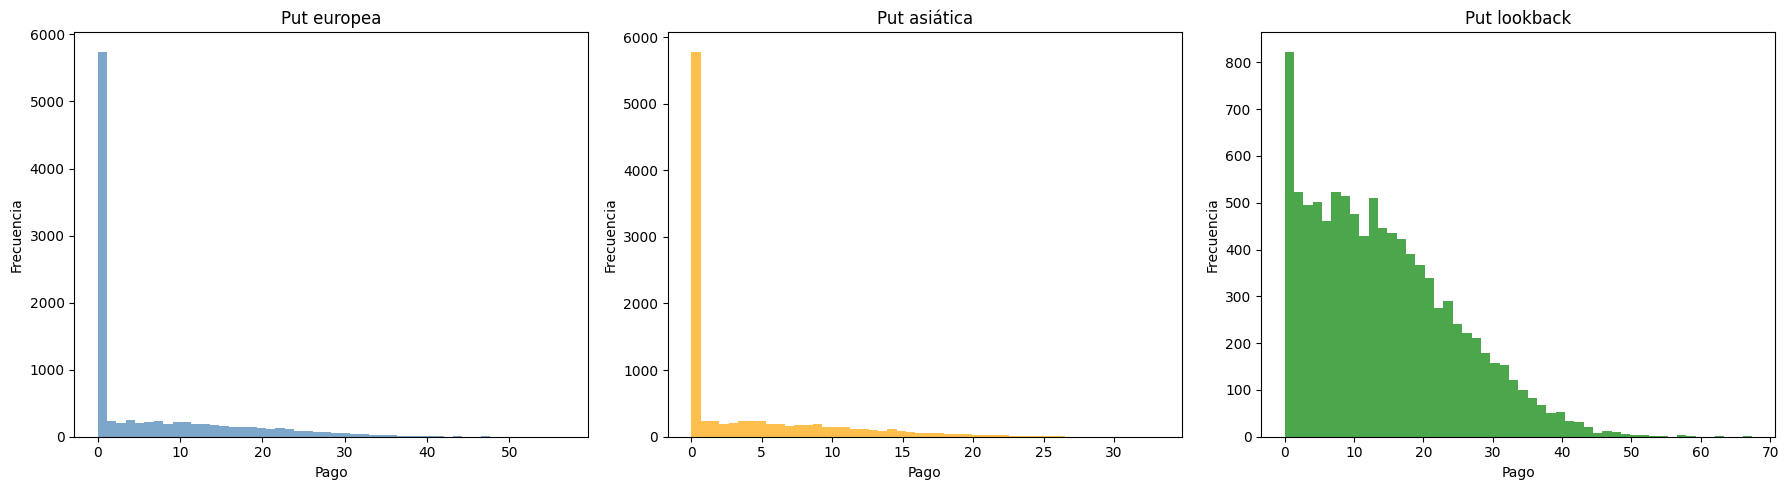

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pagos, titulo, color in zip(
        axes,
        [payoff_put_europea, payoff_put_asiatica, payoff_put_lookback],
        ["Put europea", "Put asiática", "Put lookback"],
        ["steelblue", "orange", "green"]):
    ax.hist(pagos, bins=50, alpha=0.7, color=color)
    ax.set_title(titulo)
    ax.set_xlabel("Pago")
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

Los tres histogramas comparten una masa concentrada en el pago nulo seguida de una cola hacia la derecha, aunque con proporciones muy distintas, ya que la europea y la asiática acumulan más de la mitad de las trayectorias en el cero mientras que la lookback desplaza casi toda su masa hacia pagos positivos y por eso necesita un eje vertical un orden de magnitud menor.

La cola también se comporta de forma distinta entre los dos primeros contratos, pues la escala horizontal de la put europea se extiende hasta cerca de 57 pesos y la de la asiática se detiene alrededor de 33, lo cual confirma que promediar el camino no sólo recorta la frecuencia del pago sino también su magnitud máxima, comprimiendo la distribución por ambos lados.

## 5. Opciones de barrera

In [10]:
VP_put_up_and_in, EE_put_up_and_in = valor_presente(payoff_put_up_and_in)
VP_put_up_and_out, EE_put_up_and_out = valor_presente(payoff_put_up_and_out)
VP_put_down_and_in, EE_put_down_and_in = valor_presente(payoff_put_down_and_in)
VP_put_down_and_out, EE_put_down_and_out = valor_presente(payoff_put_down_and_out)

print(f"Valor presente de la put up-and-in    (B = {B_alta}): {VP_put_up_and_in:8.4f}   error estándar {EE_put_up_and_in:.4f}")
print(f"Valor presente de la put up-and-out   (B = {B_alta}): {VP_put_up_and_out:8.4f}   error estándar {EE_put_up_and_out:.4f}")
print(f"Valor presente de la put down-and-in  (B = {B_baja}): {VP_put_down_and_in:8.4f}   error estándar {EE_put_down_and_in:.4f}")
print(f"Valor presente de la put down-and-out (B = {B_baja}): {VP_put_down_and_out:8.4f}   error estándar {EE_put_down_and_out:.4f}")

print()
print(f"Suma up-and-in + up-and-out:     {VP_put_up_and_in + VP_put_up_and_out:.4f}")
print(f"Suma down-and-in + down-and-out: {VP_put_down_and_in + VP_put_down_and_out:.4f}")
print(f"Put europea sin barrera:         {VP_put_europea:.4f}")

Valor presente de la put up-and-in    (B = 110):   1.2038   error estándar 0.0396
Valor presente de la put up-and-out   (B = 110):   4.4512   error estándar 0.0833
Valor presente de la put down-and-in  (B = 80):   3.8971   error estándar 0.0856
Valor presente de la put down-and-out (B = 80):   1.7579   error estándar 0.0384

Suma up-and-in + up-and-out:     5.6550
Suma down-and-in + down-and-out: 5.6550
Put europea sin barrera:         5.6550


Las cuatro barreras reparten el valor de la put europea sin crearlo ni destruirlo, ya que la up-and-in vale 1.2038 y la up-and-out 4.4512, mientras que la down-and-in vale 3.8971 y la down-and-out 1.7579, y ambas parejas suman 5.6550, que es exactamente el precio del contrato sin barrera.

La igualdad no es una coincidencia numérica sino una identidad, pues cada trayectoria toca la barrera o no la toca y su pago se asigna por completo a una sola de las dos variantes, de modo que la paridad se cumple camino por camino y sirve aquí como prueba de que las cuatro funciones quedaron correctamente escritas.

El reparto desigual dentro de cada pareja es el resultado que merece atención, ya que la barrera alta deja 78.7% del valor en la variante out y la baja deja 68.9% en la variante in, con lo cual un mismo strike sobre un mismo activo produce contratos de comportamiento casi opuesto según el nivel que se vigile.

Cada precio de barrera llega acompañado de su error estándar, entre 0.0384 y 0.0856, y esa magnitud no sigue al tamaño del precio sino a la dispersión del pago, de modo que la up-and-in resulta la estimación relativamente menos precisa del conjunto al valer 1.2038 con un error de 0.0396, mientras que la down-and-in alcanza un error de 0.0856 casi idéntico al 0.0862 de la europea, lo cual indica que buena parte de la variabilidad del contrato sin barrera proviene justamente de los caminos que llegan a tocar 80.

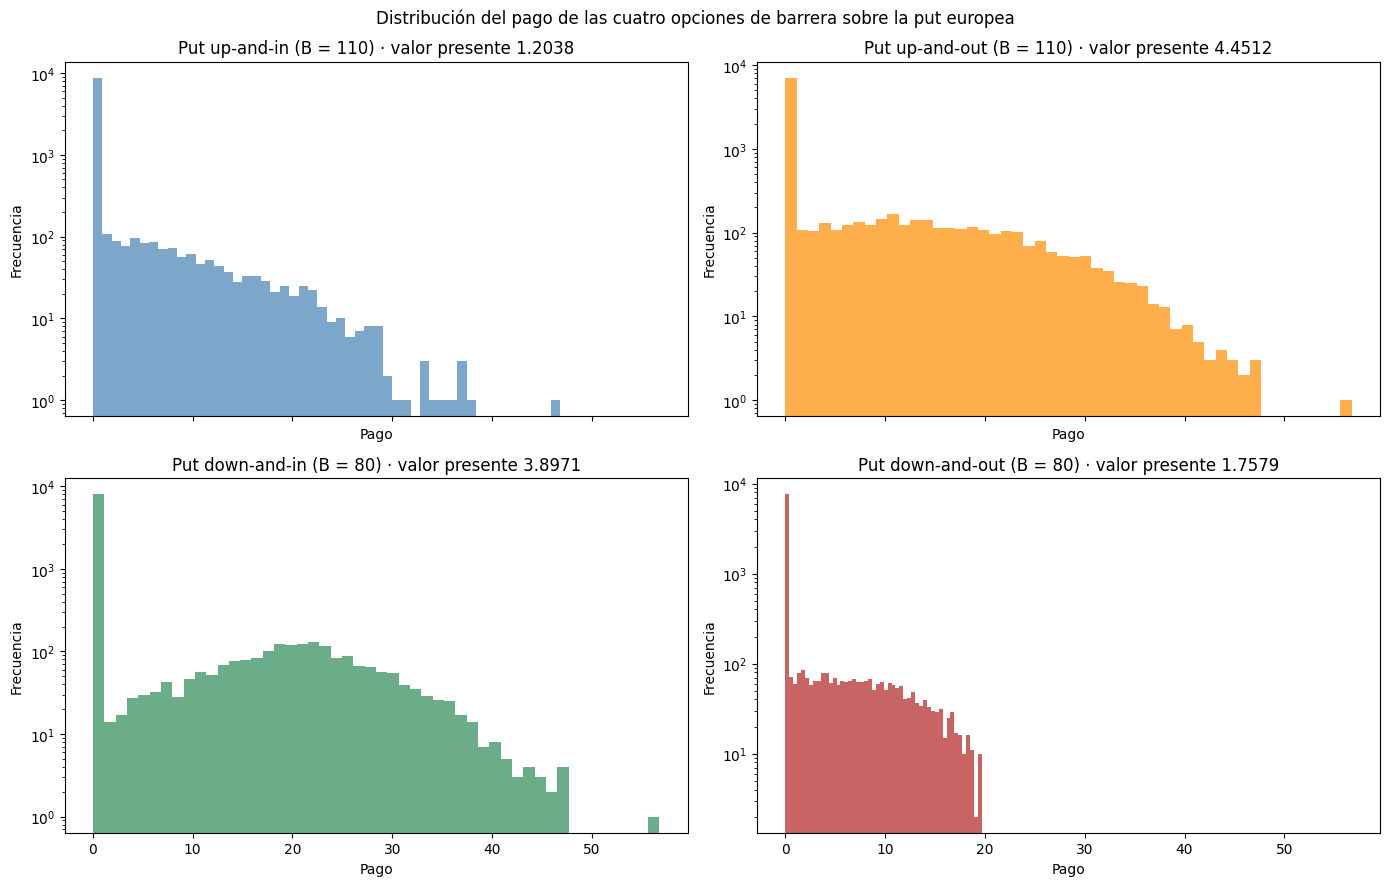

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
barreras = [
    (payoff_put_up_and_in, f"Put up-and-in (B = {B_alta})", "steelblue"),
    (payoff_put_up_and_out, f"Put up-and-out (B = {B_alta})", "darkorange"),
    (payoff_put_down_and_in, f"Put down-and-in (B = {B_baja})", "seagreen"),
    (payoff_put_down_and_out, f"Put down-and-out (B = {B_baja})", "firebrick"),
]
for ax, (pagos, titulo, color) in zip(axes.ravel(), barreras):
    ax.hist(pagos, bins=50, alpha=0.7, color=color)
    ax.set_title(f"{titulo} · valor presente {descuento * np.mean(pagos):.4f}")
    ax.set_xlabel("Pago")
    ax.set_ylabel("Frecuencia")
    ax.set_yscale("log")

fig.suptitle("Distribución del pago de las cuatro opciones de barrera sobre la put europea")
plt.tight_layout()
plt.show()

La forma de cada distribución explica el reparto mejor que las cifras agregadas, pues la down-and-in concentra su masa alrededor de pagos cercanos a 20 pesos porque sólo sobrevive en los escenarios de caída pronunciada, mientras que la up-and-in paga en muy pocos casos y por montos pequeños, dado que tocar 110 hace improbable que el precio regrese por debajo del strike antes del vencimiento.

La put down-and-out exhibe además un límite estructural que la escala logarítmica vuelve visible, ya que su pago se interrumpe de forma abrupta y no puede superar los 20 pesos que separan al strike de la barrera, debido a que cualquier precio final por debajo de 80 implica necesariamente que la barrera fue tocada y que el contrato se extinguió antes de llegar al vencimiento.

## 6. Conclusiones

El ejercicio confirma que el camino, y no solamente el destino, determina el valor de un contrato, ya que tres opciones escritas sobre el mismo activo, con el mismo strike y sobre las mismas 10,000 trayectorias, se valúan en 5.6550, 3.3529 y 13.5926 pesos según miren el precio final, el promedio del recorrido o su máximo.

La explicación es estadística antes que financiera, pues promediar 253 precios reduce la dispersión de la variable observada y la mantiene cerca del strike, mientras que tomar el máximo selecciona de manera deliberada el extremo superior de la distribución y produce un pago positivo en casi cualquier escenario, de modo que el precio de cada contrato hereda la dispersión de la variable sobre la cual está escrito.

En las opciones de barrera esa dependencia se vuelve discontinua, ya que el pago no cambia de forma sino de existencia, y por ello la asimetría entre el 64.82% de trayectorias que alcanzan 110 y el 21.18% que alcanzan 80 se traduce de inmediato en el reparto del valor, dejando 78.7% del precio en la up-and-out y 68.9% en la down-and-in.

La consecuencia práctica es que una barrera funciona como un abaratamiento dirigido y no como un descuento general, pues la put down-and-out cuesta 1.7579 frente a los 5.6550 de la europea y conserva la protección únicamente mientras la caída sea moderada, lo cual la vuelve adecuada para quien teme un retroceso ordenado, mientras que la down-and-in cuesta 3.8971 y hace exactamente lo contrario al activarse sólo en el escenario severo que la otra abandona.

El análisis tiene dos límites que conviene declarar antes de extrapolarlo, ya que el monitoreo discreto sobre los cierres diarios subestima el valor de las variantes in y sobreestima el de las out frente a una barrera vigilada de forma continua, y además cada precio aquí reportado es un promedio sobre 10,000 trayectorias que arrastra un error estándar de entre 0.0384 y 0.0988 pesos según el contrato, de manera que el orden entre ellos es sólido porque las diferencias lo superan con holgura, mientras que las cifras individuales no deben leerse más allá de la primera decimal.

La extensión natural del ejercicio es contrastar los cuatro precios de barrera contra su forma cerrada, que existe para el caso de monitoreo continuo, ya que esa comparación permitiría medir el sesgo de discretización en pesos en lugar de únicamente argumentar su dirección, y repetir después la simulación con un paso más fino para verificar que la diferencia se reduce conforme la malla se refina.